In [27]:
import os
import sys
import cv2
import matplotlib.pyplot as plt

def show_img(image, title: str = "", cmap: str = None, figsize: tuple = (10, 4)):
    """Displays an OpenCV image inline in Jupyter Notebook."""
    if image is None:
        print("Error: Image is None.")
        return

    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or 'gray')
    elif len(image.shape) == 3 and image.shape[2] == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image)

    if title:
        plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

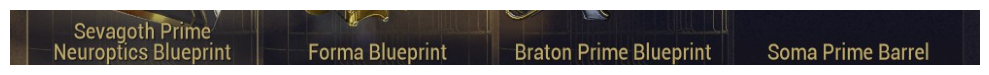

In [28]:
import os
import sys
import cv2
import numpy as np


# Filter out internal Jupyter/IPython flags (e.g. --f=kernel.json)
args = [a for a in sys.argv[1:] if not a.startswith('-')]

input_path = args[0] if args else r"G:\Programming\Repos\Warframe Relic Tracker\debug\captures\capture.png"

if not os.path.exists(input_path):
    print(f"No input image found at '{input_path}'.")
    print("Usage: python src/preprocess.py [path_to_captured_image]")
    sys.exit(1)

frame = cv2.imread(input_path)
if frame is None:
    print(f"Failed to read image: '{input_path}'")
    sys.exit(1)
    
show_img(frame)

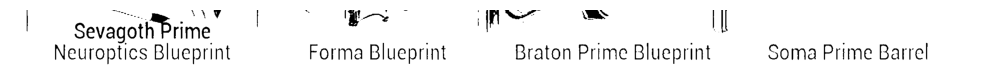

In [73]:
scaled = cv2.resize(frame, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

gray = cv2.cvtColor(scaled, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=50.0, tileGridSize=(2, 2))
enhanced = clahe.apply(gray)

normalized = cv2.normalize(enhanced, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

_, preprocessed = cv2.threshold(normalized, 235, 235, cv2.THRESH_BINARY)

ocr_ready = cv2.bitwise_not(preprocessed)

show_img(ocr_ready, cmap='gray')


In [76]:
from winocr import recognize_cv2_sync # type: ignore


def recognize_text(image):
    """
    Runs OCR on a single image (expects one item's cleaned name text,
    e.g. output of preprocess.preprocess_frame). Returns the raw
    recognized text as a single string (may include line breaks for
    wrapped two-line names).

    `recognize_cv2_sync` handles the async Windows Runtime call
    internally, so this stays a plain synchronous function from the
    caller's perspective.
    """
    result = recognize_cv2_sync(image)
    return result["text"].strip()


if __name__ == "__main__":
    # Manual test: run against saved per-item images produced by
    # preprocess.py's test block (debug/captures/item_N_clean.png).
    # Only works on Windows.
    import glob
    import os
    import cv2

    paths = sorted(glob.glob("G:/Programming/Repos/Warframe Relic Tracker/debug/captures/item_*_clean.png"))
    if not paths:
        print("No cleaned item images found in debug/captures/.")
        print("Run 'python src/preprocess.py <capture>' first.")
    else:
        for path in paths:
            img = cv2.imread(path)
            text = recognize_text(img)
            print(f"{os.path.basename(path)} -> {text!r}")

RuntimeError: asyncio.run() cannot be called from a running event loop